<a href="https://colab.research.google.com/github/Fariba-Diya-Ahmed/Air-Quality-Analysis-using-ML/blob/main/AQI_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CSV file

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

path = '/content/drive/MyDrive/AI_project/aqi_dataset/AQI Bangladesh.csv'

df = pd.read_csv(path)

# convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])


Mounted at /content/drive


Data cleaning

In [3]:
# last 6 months
df = df[df['datetime'] >= df['datetime'].max() - pd.DateOffset(months=6)]

# Sylhet Filter
df = df[df['city_name'] == 'Sylhet'].copy()

# Time features
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

# drop unnecessary columns
df.drop(columns=[
    'city_id',
    'city_name',
    'lat',
    'lon',
    'carbon_dioxide',
    'datetime'
], inplace=True)

# check null
print(df.isnull().sum())

print(df.head())
print(df.info())
print(df.describe())

pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
aqi                 0
month               0
hour                0
dtype: int64
         pm10  pm2_5  carbon_monoxide  nitrogen_dioxide  sulphur_dioxide  \
2956845  30.0   23.6            274.0              13.6              4.5   
2956846  28.3   21.8            285.0              11.0              2.9   
2956847  22.9   17.5            275.0               8.9              2.7   
2956848  19.3   15.0            254.0               6.1              2.5   
2956849  17.8   13.6            235.0               3.8              2.4   

         ozone   aqi  month  hour  
2956845   55.0  82.0      5    23  
2956846   60.0  79.0      5     0  
2956847   66.0  76.0      5     1  
2956848   76.0  73.0      5     2  
2956849   87.0  71.0      5     3  
<class 'pandas.core.frame.DataFrame'>
Index: 4417 entries, 2956845 to 2961261
Data columns (total 9 columns):
 #   C

Exploratory data analysis (EDA)

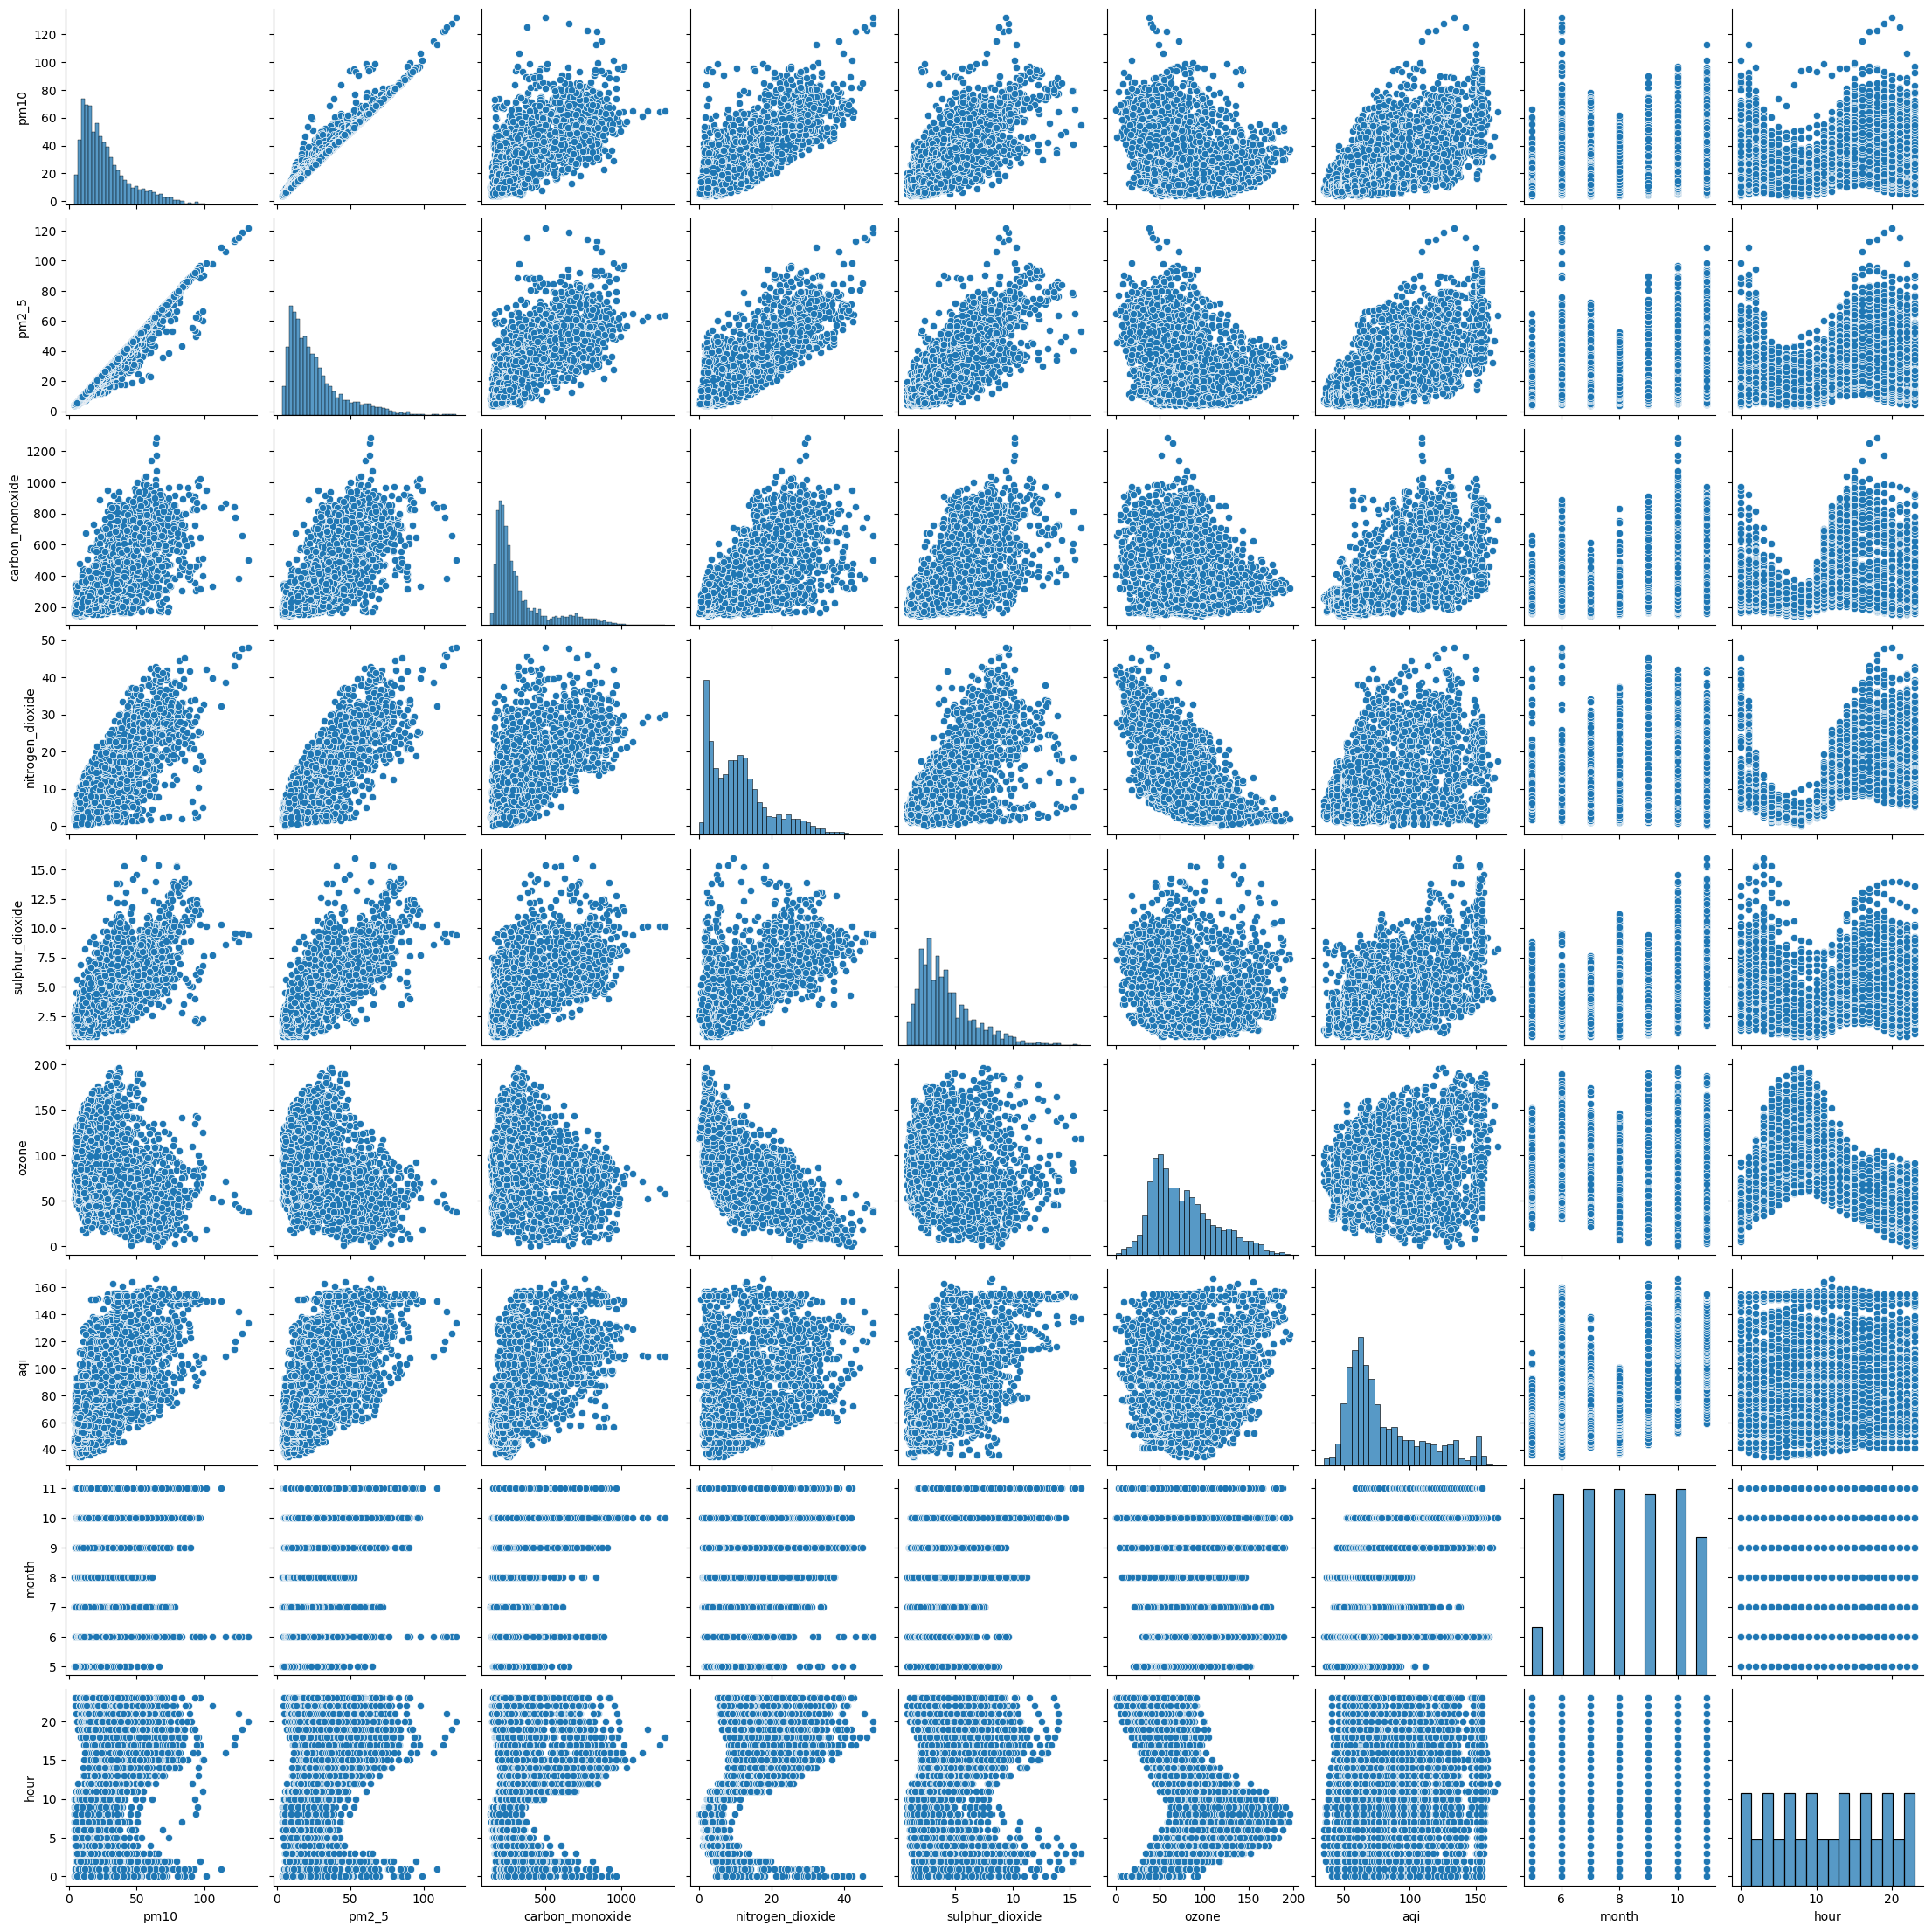

In [4]:
sns.pairplot(df[['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone','aqi','month','hour']])

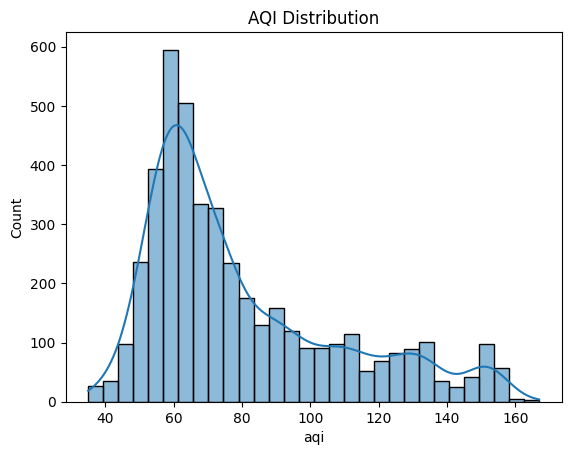

In [5]:
# Histogram of AQI
sns.histplot(df['aqi'], bins=30, kde=True)
plt.title("AQI Distribution")
plt.show()




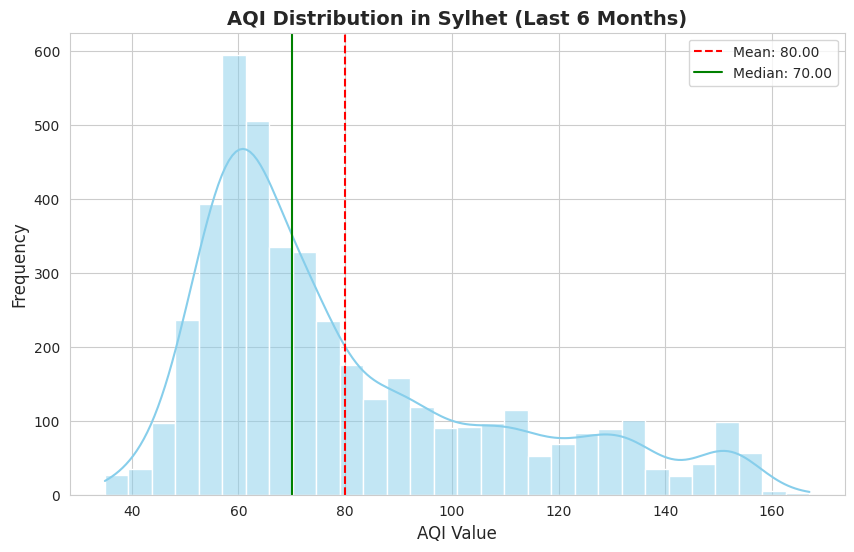

In [6]:
sns.set_style("whitegrid")  # Clean background
plt.figure(figsize=(10,6))  # Bigger figure

sns.histplot(df['aqi'], bins=30, kde=True, color="skyblue")

plt.axvline(df['aqi'].mean(), color='red', linestyle='--', label=f"Mean: {df['aqi'].mean():.2f}")
plt.axvline(df['aqi'].median(), color='green', linestyle='-', label=f"Median: {df['aqi'].median():.2f}")

plt.title("AQI Distribution in Sylhet (Last 6 Months)", fontsize=14, fontweight='bold')
plt.xlabel("AQI Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()


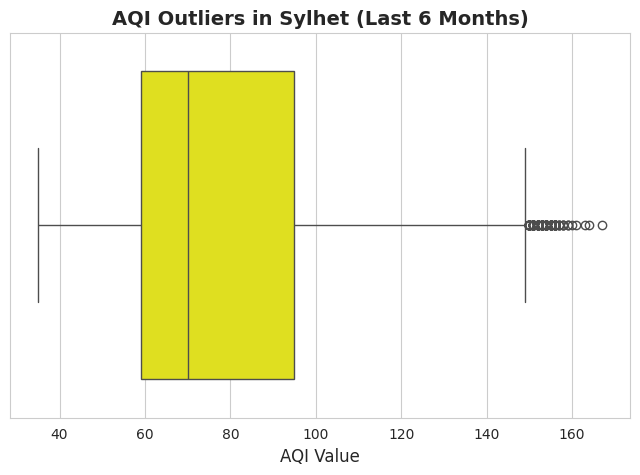

In [7]:
#boxplot

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.boxplot(x=df['aqi'], color="yellow")

plt.title("AQI Outliers in Sylhet (Last 6 Months)", fontsize=14, fontweight='bold')
plt.xlabel("AQI Value", fontsize=12)
plt.show()


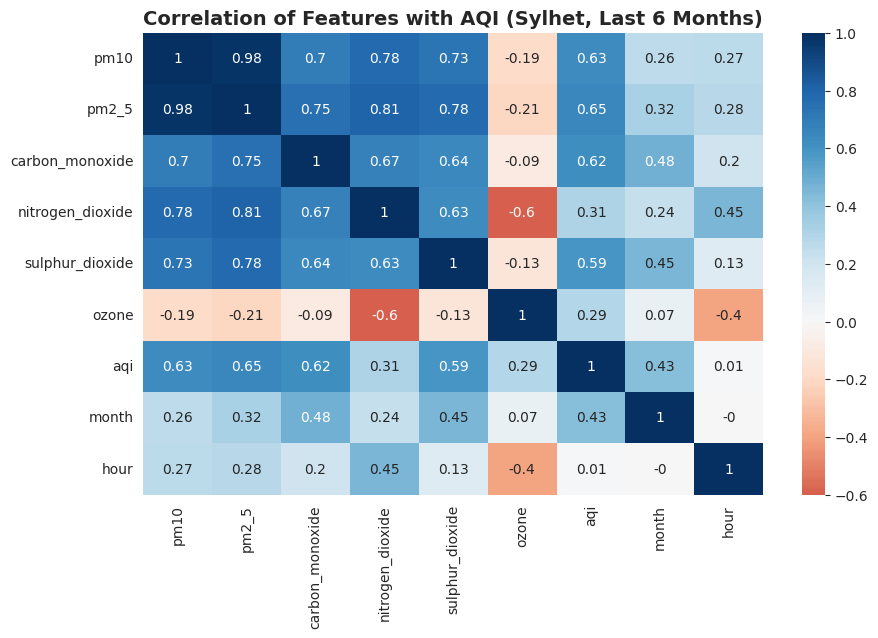

In [8]:
# Correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr().round(2), annot=True, cmap="RdBu", center=0)

plt.title("Correlation of Features with AQI (Sylhet, Last 6 Months)", fontsize=14, fontweight='bold')
plt.show()



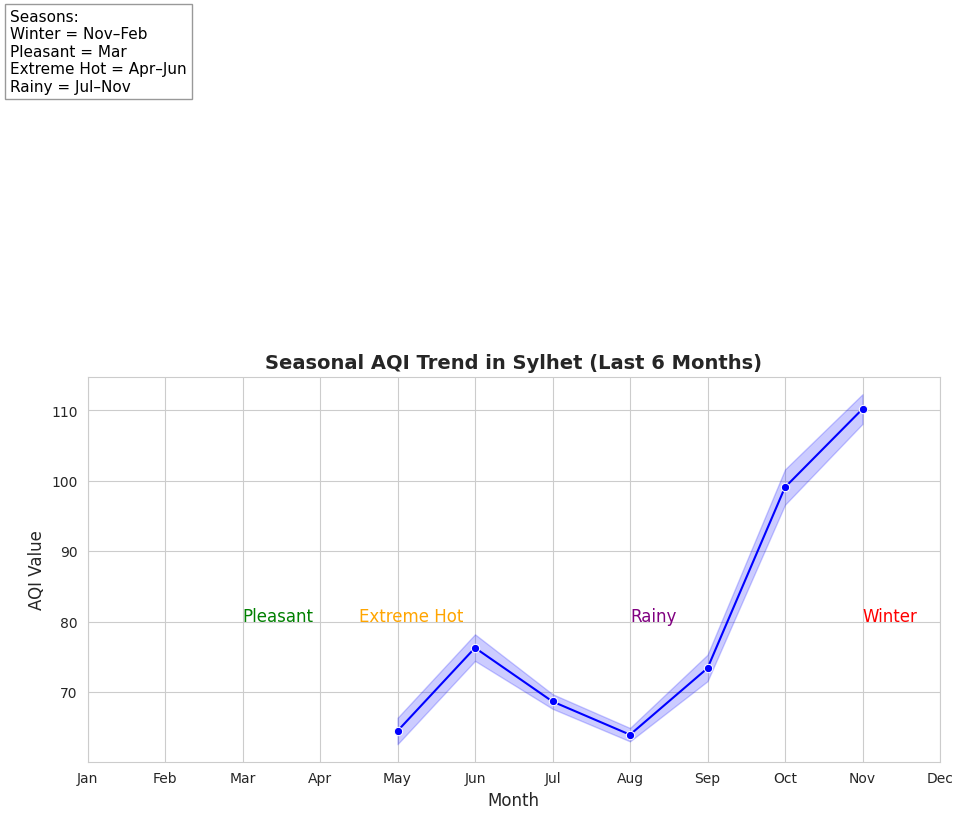

In [9]:
# Season mapping
season_map = {
    11: "Winter", 12: "Winter", 1: "Winter", 2: "Winter",
    3: "Pleasant",
    4: "Extreme Hot", 5: "Extreme Hot", 6: "Extreme Hot",
    7: "Rainy", 8: "Rainy", 9: "Moderate hot", 10: "Rainy"
}
df['season'] = df['month'].map(season_map)

plt.figure(figsize=(11,5))
sns.lineplot(x=df['month'], y=df['aqi'], marker="o", color="blue")

# X-axis labels as month names
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12],
           ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

# Season annotations
plt.text(11, df['aqi'].mean(), "Winter", fontsize=12, color="red")
plt.text(3, df['aqi'].mean(), "Pleasant", fontsize=12, color="green")
plt.text(4.5, df['aqi'].mean(), "Extreme Hot", fontsize=12, color="orange")
plt.text(8, df['aqi'].mean(), "Rainy", fontsize=12, color="purple")

# Season note box (upper right corner)
season_text = (
    "Seasons:\n"
    "Winter = Nov–Feb\n"
    "Pleasant = Mar\n"
    "Extreme Hot = Apr–Jun\n"
    "Rainy = Jul–Nov"
)
plt.text(0, df['aqi'].max(), season_text,
         fontsize=11, color="black", ha="left", va="top",
         bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

plt.title("Seasonal AQI Trend in Sylhet (Last 6 Months)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("AQI Value", fontsize=12)

plt.show()


/tmp/ipykernel_10927/1546976467.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x=df['hour'], y=df['aqi'], marker="o", color="orange", ci=None)


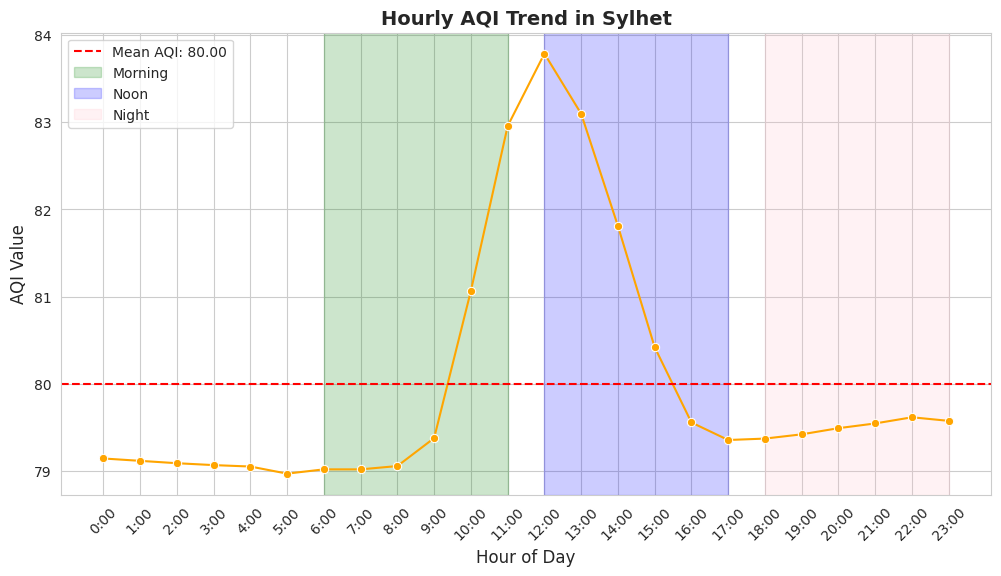

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(x=df['hour'], y=df['aqi'], marker="o", color="orange", ci=None)

# Mean AQI line
plt.axhline(df['aqi'].mean(), color='red', linestyle='--', label=f"Mean AQI: {df['aqi'].mean():.2f}")

# X-axis labels
plt.xticks(range(0,24), [f"{h}:00" for h in range(0,24)], rotation=45)

# Background shading for morning, noon, night
plt.axvspan(6, 11, color="green", alpha=0.2, label="Morning")
plt.axvspan(12, 17, color="blue", alpha=0.2, label="Noon")
plt.axvspan(18, 23, color="pink", alpha=0.2, label="Night")

plt.title("Hourly AQI Trend in Sylhet", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("AQI Value", fontsize=12)
plt.legend()
plt.show()


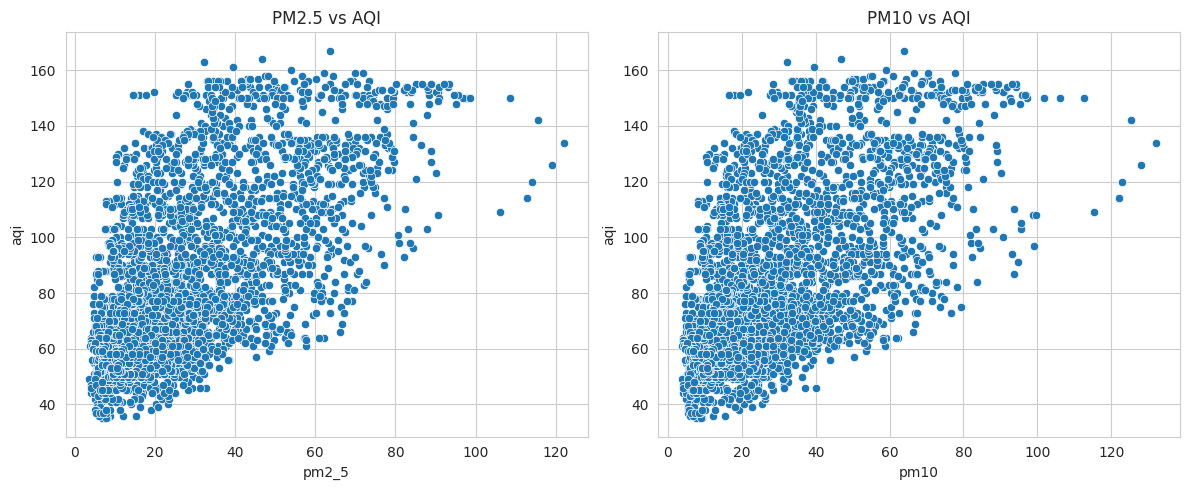

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='pm2_5', y='aqi', data=df)
plt.title("PM2.5 vs AQI")

plt.subplot(1,2,2)
sns.scatterplot(x='pm10', y='aqi', data=df)
plt.title("PM10 vs AQI")

plt.tight_layout()
plt.show()

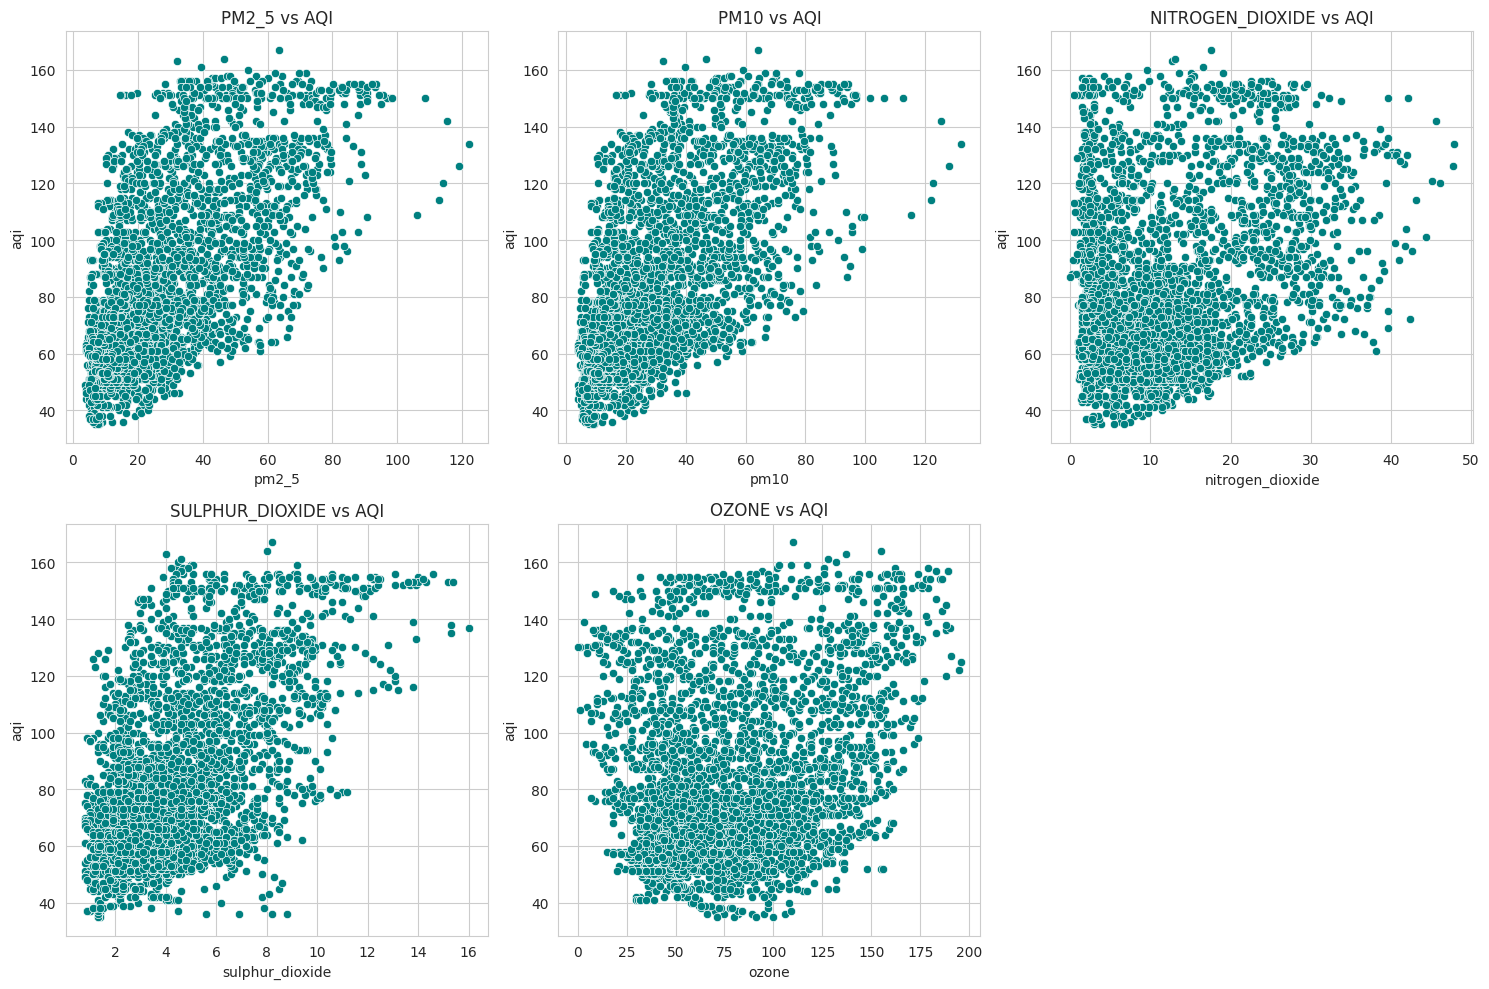

In [12]:

features = ['pm2_5', 'pm10', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.scatterplot(x=feature, y='aqi', data=df, color="teal")
    plt.title(f"{feature.upper()} vs AQI")

plt.tight_layout()
plt.show()


In [13]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features and target
X = df[['pm2_5', 'pm10', 'nitrogen_dioxide', 'sulphur_dioxide', 'carbon_monoxide', 'ozone']]   # select main impactful features
y = df['aqi']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Regression model
knn = KNeighborsRegressor(n_neighbors=5)   # you can tune n_neighbors
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

print("Predicted AQI:", y_pred[0])

# status mapping
predicted_aqi = y_pred[0]

if predicted_aqi <= 50:
    status = "Good"
elif predicted_aqi <= 100:
    status = "Moderate"
elif predicted_aqi <= 150:
    status = "Unhealthy for Sensitive Groups"
elif predicted_aqi <= 200:
    status = "Harmful"
elif predicted_aqi <= 300:
    status = "Very Harmful"
else:
    status = "Severe"

print("Status:", status)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)


Predicted AQI: 71.8
Status: Moderate
RMSE: 16.563436262276003
MAE: 12.089592760180993
R² Score: 0.6526287543902781


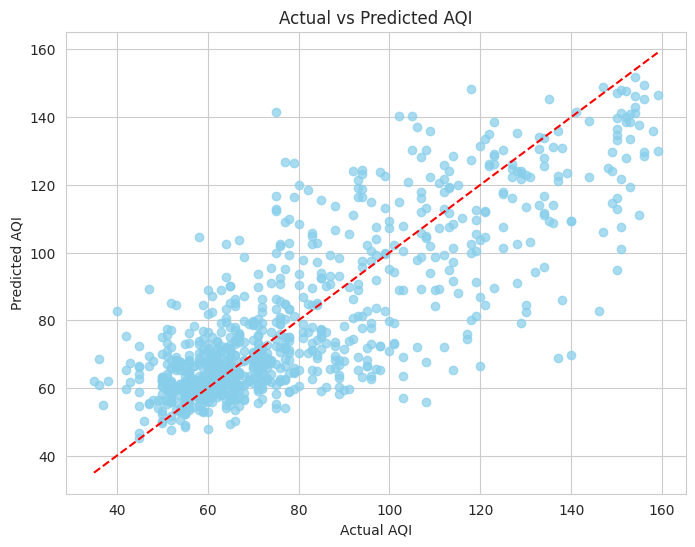

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color="skyblue", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

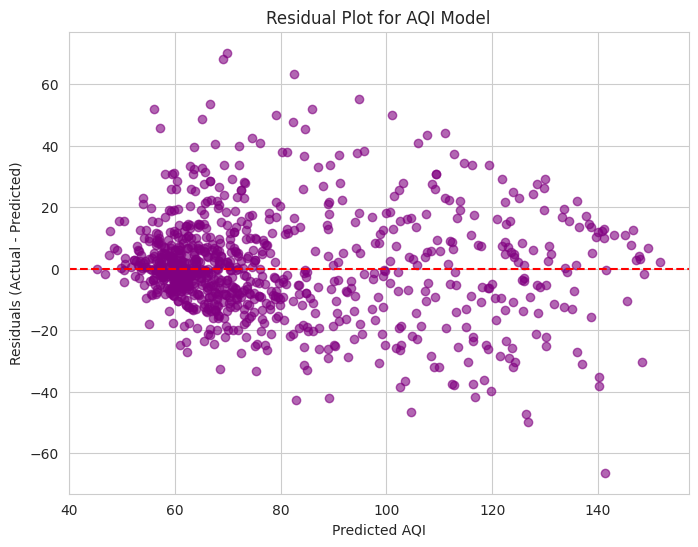

In [15]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color="purple", alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for AQI Model")
plt.show()
